In [23]:
# Install required packages
!pip install torch torchvision torchaudio torch-geometric -q
!pip install tqdm scikit-learn matplotlib pandas numpy opencv-python networkx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 41.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 36.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 9.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 7.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [24]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html


In [25]:
!pip install numpy pandas scikit-learn matplotlib seaborn tqdm wfdb
!pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html


Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
Balanced dataset size: 15000


100%|██████████| 15000/15000 [19:59<00:00, 12.51it/s]


Number of graphs created: 15000
Train: 12000, Val: 1500, Test: 1500
Epoch 1/100, Loss: 1.2576, Train Acc: 0.4567, Val Acc: 0.5720
Epoch 2/100, Loss: 1.0928, Train Acc: 0.5609, Val Acc: 0.5940
Epoch 3/100, Loss: 1.0498, Train Acc: 0.5779, Val Acc: 0.6047
Epoch 4/100, Loss: 1.0206, Train Acc: 0.5980, Val Acc: 0.6093
Epoch 5/100, Loss: 0.9885, Train Acc: 0.6138, Val Acc: 0.5907
Epoch 6/100, Loss: 0.9681, Train Acc: 0.6204, Val Acc: 0.6240
Epoch 7/100, Loss: 0.9370, Train Acc: 0.6345, Val Acc: 0.6373
Epoch 8/100, Loss: 0.9220, Train Acc: 0.6397, Val Acc: 0.6420
Epoch 9/100, Loss: 0.8957, Train Acc: 0.6540, Val Acc: 0.6347
Epoch 10/100, Loss: 0.8843, Train Acc: 0.6592, Val Acc: 0.6020
Epoch 11/100, Loss: 0.8668, Train Acc: 0.6663, Val Acc: 0.6513
Epoch 12/100, Loss: 0.8445, Train Acc: 0.6767, Val Acc: 0.6547
Epoch 13/100, Loss: 0.8256, Train Acc: 0.6850, Val Acc: 0.6667
Epoch 14/100, Loss: 0.8083, Train Acc: 0.6917, Val Acc: 0.6507
Epoch 15/100, Loss: 0.7888, Train Acc: 0.7011, Val Acc: 0.6

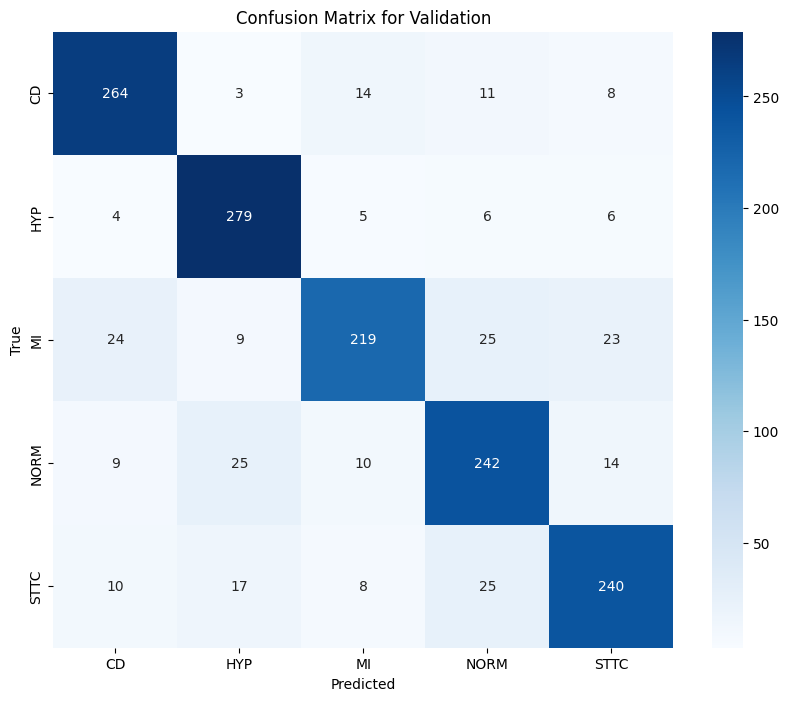

Validation Accuracy: 0.8293

Classification Report for Test:
              precision    recall  f1-score   support

          CD     0.8614    0.8700    0.8657       300
         HYP     0.7954    0.9200    0.8532       300
          MI     0.8309    0.7533    0.7902       300
        NORM     0.8256    0.7733    0.7986       300
        STTC     0.8047    0.7967    0.8007       300

    accuracy                         0.8227      1500
   macro avg     0.8236    0.8227    0.8217      1500
weighted avg     0.8236    0.8227    0.8217      1500



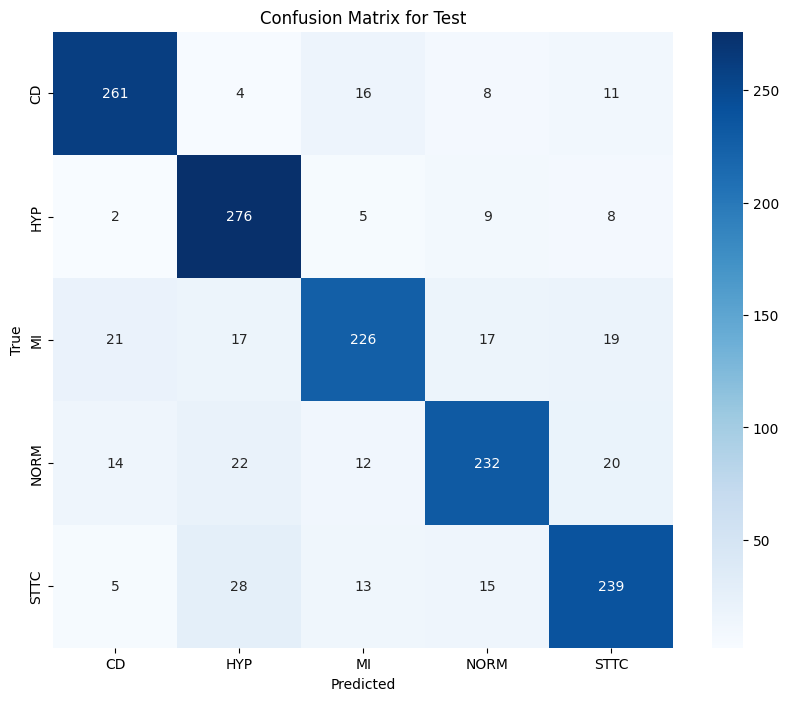

Test Accuracy: 0.8227


In [16]:
import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.fft import fft
import os
from tqdm import tqdm

# Step 1: Set Up the Environment
# Install required libraries (already available in Kaggle)
# !pip install wfdb torch-geometric

# Step 2: Load and Balance the PTB-XL Dataset
def load_and_balance_ptbxl_data(data_path, samples_per_class=3000):
    metadata = pd.read_csv(os.path.join(data_path, 'ptbxl_database.csv'))
    scp_statements = pd.read_csv(os.path.join(data_path, 'scp_statements.csv'))
    
    diagnostic_scp = scp_statements[scp_statements['diagnostic'] == 1]
    valid_statements = diagnostic_scp['Unnamed: 0'].values
    
    def get_superclass(scp_codes):
        scp_codes = eval(scp_codes) if isinstance(scp_codes, str) else scp_codes
        for code, likelihood in scp_codes.items():
            if code in valid_statements and likelihood > 0:
                superclass = diagnostic_scp[diagnostic_scp['Unnamed: 0'] == code]['diagnostic_class'].values
                if len(superclass) > 0:
                    return superclass[0]
        return None
    
    metadata['superclass'] = metadata['scp_codes'].apply(get_superclass)
    metadata = metadata[metadata['superclass'].notnull()]
    
    label_encoder = LabelEncoder()
    metadata['label'] = label_encoder.fit_transform(metadata['superclass'])
    classes = label_encoder.classes_
    
    balanced_metadata = pd.DataFrame()
    for class_name in classes:
        class_data = metadata[metadata['superclass'] == class_name]
        if len(class_data) > samples_per_class:
            class_data = resample(class_data, n_samples=samples_per_class, random_state=42)
        elif len(class_data) < samples_per_class:
            class_data = resample(class_data, n_samples=samples_per_class, replace=True, random_state=42)
        balanced_metadata = pd.concat([balanced_metadata, class_data])
    
    balanced_metadata = balanced_metadata.reset_index(drop=True)
    
    return balanced_metadata, classes

# Step 3: Convert ECG Signals to Graphs (With FFT Features)
def ecg_to_graph(signal, label, window_size=1000, k=5):
    # Normalize signal
    signal = (signal - np.mean(signal, axis=0)) / (np.std(signal, axis=0) + 1e-8)
    
    if signal.shape[0] < window_size:
        signal = np.pad(signal, ((0, window_size - signal.shape[0]), (0, 0)), mode='constant')
    else:
        signal = signal[:window_size, :]
    
    num_nodes = window_size
    node_features = np.zeros((num_nodes, 16))  # 12 leads + mean + std + 2 FFT
    for t in range(num_nodes):
        features = signal[t, :]
        node_features[t, :12] = features
        node_features[t, 12:14] = [np.mean(signal[t, :]), np.std(signal[t, :])]
        fft_vals = np.abs(fft(signal[t, :]))[:2]  # First two FFT coefficients
        node_features[t, 14:] = fft_vals / (np.max(fft_vals) + 1e-8)  # Normalize FFT
    
    node_features = torch.from_numpy(node_features).float()
    
    edge_index = []
    for i in range(num_nodes):
        for j in range(i + 1, min(i + k + 1, num_nodes)):
            edge_index.append([i, j])
            edge_index.append([j, i])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    data = Data(x=node_features, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))
    return data

# Step 4: Create Dataset
def create_dataset(metadata, data_path, window_size=1000, k=5, sampling_rate=100):
    graphs = []
    valid_indices = []
    for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
        ecg_id = row['ecg_id']
        label = row['label']
        file_path = os.path.join(data_path, row['filename_lr'])
        try:
            signal, _ = wfdb.rdsamp(file_path.replace('.dat', ''))
            graph = ecg_to_graph(signal, label, window_size, k)
            graphs.append(graph)
            valid_indices.append(idx)
        except Exception as e:
            print(f"Error processing ECG {ecg_id}: {e}")
            continue
    valid_metadata = metadata.loc[valid_indices].reset_index(drop=True)
    return graphs, valid_metadata

# Step 5: Split Dataset (80/10/10)
def split_dataset(metadata, graphs):
    if len(metadata) != len(graphs):
        raise ValueError(f"Mismatch between metadata ({len(metadata)}) and graphs ({len(graphs)})")
    
    train_idx, test_idx = train_test_split(
        metadata.index, test_size=0.2, stratify=metadata['label'], random_state=42
    )
    val_idx, test_idx = train_test_split(
        test_idx, test_size=0.5, stratify=metadata.loc[test_idx, 'label'], random_state=42
    )
    
    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]
    
    return train_graphs, val_graphs, test_graphs

# Step 6: Define GNN Model with GATConv
class ECGGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(ECGGNN, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=4, concat=True)
        self.conv2 = GATConv(hidden_dim * 4, hidden_dim, heads=4, concat=True)
        self.conv3 = GATConv(hidden_dim * 4, hidden_dim, heads=1, concat=False)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, data.batch)
        x = self.fc(x)
        return x

# Step 7: Training Loop
def train_model(model, train_loader, val_loader, device, classes, epochs=100, lr=0.0005):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.2, 1.5, 1.5, 1.0, 1.2]).to(device))  # Higher weights for HYP, MI
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.y.size(0)
        
        train_acc = correct / total
        val_acc = simple_evaluate_model(model, val_loader, device)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
        
        scheduler.step(val_acc)
        
        if val_acc >= 0.90:
            print("Achieved 90%+ validation accuracy. Stopping training.")
            break
    return model

# Step 8: Simplified Evaluation for Training
def simple_evaluate_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.y.size(0)
    return correct / total

# Step 9: Detailed Evaluation with Classification Report and Confusion Matrix
def detailed_evaluate_model(model, loader, device, classes, split_name="Test"):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            trues.extend(data.y.cpu().numpy())
    
    acc = sum(p == t for p, t in zip(preds, trues)) / len(trues)
    
    print(f"\nClassification Report for {split_name}:")
    print(classification_report(trues, preds, target_names=classes, digits=4))
    
    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {split_name}')
    plt.show()
    
    return acc

# Main Execution
if __name__ == "__main__":
    data_path = "/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load and balance data
    metadata, classes = load_and_balance_ptbxl_data(data_path, samples_per_class=3000)
    print(f"Classes: {classes}")
    print(f"Balanced dataset size: {len(metadata)}")
    
    # Create dataset
    graphs, metadata = create_dataset(metadata, data_path)
    print(f"Number of graphs created: {len(graphs)}")
    
    # Split dataset
    train_graphs, val_graphs, test_graphs = split_dataset(metadata, graphs)
    print(f"Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")
    
    # Create data loaders
    train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=32)
    test_loader = DataLoader(test_graphs, batch_size=32)
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Initialize and train model
    model = ECGGNN(input_dim=16, hidden_dim=128, num_classes=len(classes)).to(device)
    model = train_model(model, train_loader, val_loader, device, classes, epochs=100, lr=0.0005)
    
    # Detailed evaluation after training
    val_acc = detailed_evaluate_model(model, val_loader, device, classes, split_name="Validation")
    print(f"Validation Accuracy: {val_acc:.4f}")
    test_acc = detailed_evaluate_model(model, test_loader, device, classes, split_name="Test")
    print(f"Test Accuracy: {test_acc:.4f}")

Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
Balanced dataset size: 15000


100%|██████████| 15000/15000 [2:22:21<00:00,  1.76it/s] 


Number of graphs created: 15000
Train: 12000, Val: 1500, Test: 1500
Epoch 1/100, Loss: 1.2547, Train Acc: 0.4563, Val Acc: 0.5460
Epoch 2/100, Loss: 1.0851, Train Acc: 0.5723, Val Acc: 0.5860
Epoch 3/100, Loss: 1.0396, Train Acc: 0.5883, Val Acc: 0.6013
Epoch 4/100, Loss: 1.0163, Train Acc: 0.5958, Val Acc: 0.5867
Epoch 5/100, Loss: 0.9912, Train Acc: 0.6094, Val Acc: 0.5920
Epoch 6/100, Loss: 0.9653, Train Acc: 0.6256, Val Acc: 0.6147
Epoch 7/100, Loss: 0.9453, Train Acc: 0.6294, Val Acc: 0.6113
Epoch 8/100, Loss: 0.9259, Train Acc: 0.6373, Val Acc: 0.6140
Epoch 9/100, Loss: 0.9106, Train Acc: 0.6469, Val Acc: 0.6320
Epoch 10/100, Loss: 0.8964, Train Acc: 0.6476, Val Acc: 0.6367
Epoch 11/100, Loss: 0.8854, Train Acc: 0.6577, Val Acc: 0.6460
Epoch 12/100, Loss: 0.8757, Train Acc: 0.6610, Val Acc: 0.6307
Epoch 13/100, Loss: 0.8574, Train Acc: 0.6725, Val Acc: 0.6467
Epoch 14/100, Loss: 0.8402, Train Acc: 0.6783, Val Acc: 0.6547
Epoch 15/100, Loss: 0.8339, Train Acc: 0.6781, Val Acc: 0.6

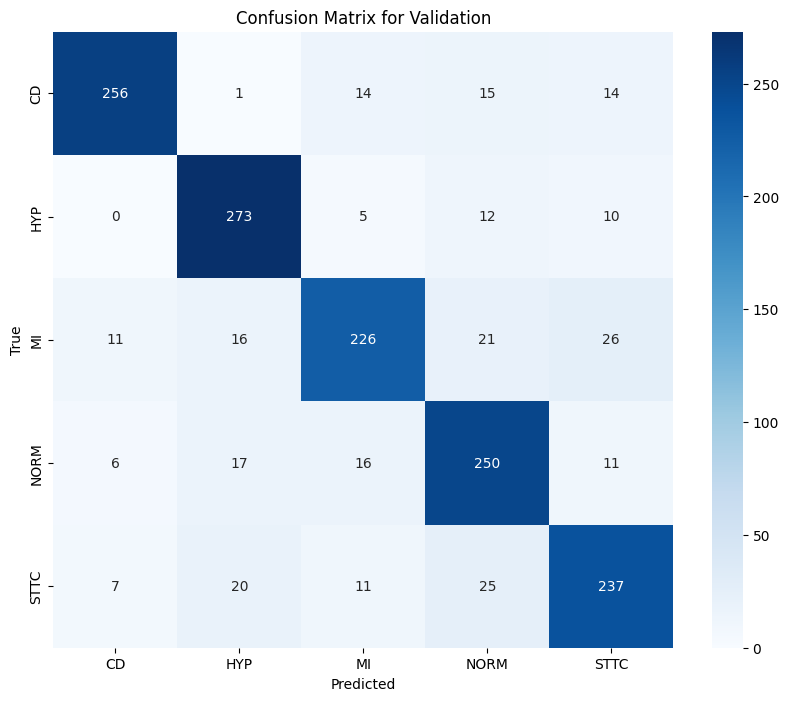

Validation Accuracy: 0.8280

Classification Report for Test:
              precision    recall  f1-score   support

          CD     0.9088    0.8300    0.8676       300
         HYP     0.8426    0.9100    0.8750       300
          MI     0.7849    0.7300    0.7565       300
        NORM     0.7771    0.8600    0.8165       300
        STTC     0.8007    0.7767    0.7885       300

    accuracy                         0.8213      1500
   macro avg     0.8228    0.8213    0.8208      1500
weighted avg     0.8228    0.8213    0.8208      1500



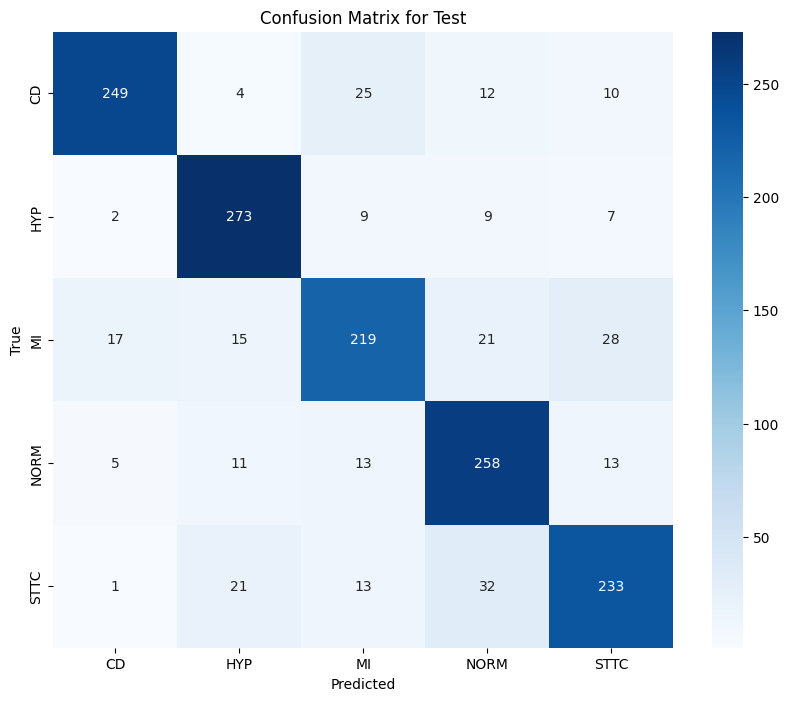

Test Accuracy: 0.8213


In [5]:
import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.fft import fft
import pywt
import os
from tqdm import tqdm

# Step 1: Set Up the Environment
# Install required libraries
# !pip install wfdb torch-geometric pywavelets
# !pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv --no-cache-dir

# Step 2: Load and Balance the PTB-XL Dataset
def load_and_balance_ptbxl_data(data_path, samples_per_class=3000):
    metadata = pd.read_csv(os.path.join(data_path, 'ptbxl_database.csv'))
    scp_statements = pd.read_csv(os.path.join(data_path, 'scp_statements.csv'))
    
    diagnostic_scp = scp_statements[scp_statements['diagnostic'] == 1]
    valid_statements = diagnostic_scp['Unnamed: 0'].values
    
    def get_superclass(scp_codes):
        scp_codes = eval(scp_codes) if isinstance(scp_codes, str) else scp_codes
        for code, likelihood in scp_codes.items():
            if code in valid_statements and likelihood > 0:
                superclass = diagnostic_scp[diagnostic_scp['Unnamed: 0'] == code]['diagnostic_class'].values
                if len(superclass) > 0:
                    return superclass[0]
        return None
    
    metadata['superclass'] = metadata['scp_codes'].apply(get_superclass)
    metadata = metadata[metadata['superclass'].notnull()]
    
    label_encoder = LabelEncoder()
    metadata['label'] = label_encoder.fit_transform(metadata['superclass'])
    classes = label_encoder.classes_
    
    balanced_metadata = pd.DataFrame()
    for class_name in classes:
        class_data = metadata[metadata['superclass'] == class_name]
        if len(class_data) > samples_per_class:
            class_data = resample(class_data, n_samples=samples_per_class, random_state=42)
        elif len(class_data) < samples_per_class:
            class_data = resample(class_data, n_samples=samples_per_class, replace=True, random_state=42)
        balanced_metadata = pd.concat([balanced_metadata, class_data])
    
    balanced_metadata = balanced_metadata.reset_index(drop=True)
    
    return balanced_metadata, classes

# Step 3: Convert ECG Signals to Graphs (With FFT and Wavelet Features)
def ecg_to_graph(signal, label, window_size=1000, k=5):
    # Normalize signal
    signal = (signal - np.mean(signal, axis=0)) / (np.std(signal, axis=0) + 1e-8)
    
    if signal.shape[0] < window_size:
        signal = np.pad(signal, ((0, window_size - signal.shape[0]), (0, 0)), mode='constant')
    else:
        signal = signal[:window_size, :]
    
    num_nodes = window_size
    node_features = np.zeros((num_nodes, 18))  # 12 leads + mean + std + 2 FFT + 2 DWT
    for t in range(num_nodes):
        features = signal[t, :]
        node_features[t, :12] = features
        node_features[t, 12:14] = [np.mean(signal[t, :]), np.std(signal[t, :])]
        fft_vals = np.abs(fft(signal[t, :]))[:2]
        node_features[t, 14:16] = fft_vals / (np.max(fft_vals) + 1e-8)
        # Discrete Wavelet Transform (DWT) using pywt
        try:
            coeffs, _ = pywt.cwt(signal[t, :], scales=[1, 2], wavelet='mexh')
            node_features[t, 16:18] = coeffs[:, 0] / (np.max(np.abs(coeffs[:, 0])) + 1e-8)
        except Exception as e:
            print(f"Wavelet transform error at time point {t}: {e}")
            node_features[t, 16:18] = 0  # Fallback to zeros
    
    node_features = torch.from_numpy(node_features).float()
    
    # k-Nearest Neighbor edges
    edge_index = []
    for i in range(num_nodes):
        for j in range(i + 1, min(i + k + 1, num_nodes)):
            edge_index.append([i, j])
            edge_index.append([j, i])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    data = Data(x=node_features, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))
    return data

# Step 4: Create Dataset
def create_dataset(metadata, data_path, window_size=1000, k=5):
    graphs = []
    valid_indices = []
    for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
        ecg_id = row['ecg_id']
        label = row['label']
        file_path = os.path.join(data_path, row['filename_lr'])
        try:
            signal, _ = wfdb.rdsamp(file_path.replace('.dat', ''))
            graph = ecg_to_graph(signal, label, window_size, k)
            graphs.append(graph)
            valid_indices.append(idx)
        except Exception as e:
            print(f"Error processing ECG {ecg_id}: {e}")
            continue
    valid_metadata = metadata.loc[valid_indices].reset_index(drop=True)
    return graphs, valid_metadata

# Step 5: Split Dataset (80/10/10)
def split_dataset(metadata, graphs):
    if len(metadata) != len(graphs):
        raise ValueError(f"Mismatch between metadata ({len(metadata)}) and graphs ({len(graphs)})")
    
    train_idx, test_idx = train_test_split(
        metadata.index, test_size=0.2, stratify=metadata['label'], random_state=42
    )
    val_idx, test_idx = train_test_split(
        test_idx, test_size=0.5, stratify=metadata.loc[test_idx, 'label'], random_state=42
    )
    
    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]
    
    return train_graphs, val_graphs, test_graphs

# Step 6: Define GNN Model with GATConv
class ECGGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(ECGGNN, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=4, concat=True)
        self.conv2 = GATConv(hidden_dim * 4, hidden_dim, heads=4, concat=True)
        self.conv3 = GATConv(hidden_dim * 4, hidden_dim, heads=1, concat=False)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.4)
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, data.batch)
        x = self.fc(x)
        return x

# Step 7: Training Loop
def train_model(model, train_loader, val_loader, device, classes, epochs=100, lr=0.0005):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.2, 1.5, 1.7, 1.3, 1.2]).to(device))
    
    best_val_acc = 0
    patience = 10
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.y.size(0)
        
        train_acc = correct / total
        val_acc = simple_evaluate_model(model, val_loader, device)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
        
        scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} due to no improvement in validation accuracy.")
                break
    
    return model

# Step 8: Simplified Evaluation for Training
def simple_evaluate_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.y.size(0)
    return correct / total

# Step 9: Detailed Evaluation with Classification Report and Confusion Matrix
def detailed_evaluate_model(model, loader, device, classes, split_name="Test"):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            trues.extend(data.y.cpu().numpy())
    
    acc = sum(p == t for p, t in zip(preds, trues)) / len(trues)
    
    print(f"\nClassification Report for {split_name}:")
    print(classification_report(trues, preds, target_names=classes, digits=4))
    
    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {split_name}')
    plt.show()
    
    return acc

# Main Execution
if __name__ == "__main__":
    data_path = "/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load and balance data
    metadata, classes = load_and_balance_ptbxl_data(data_path, samples_per_class=3000)
    print(f"Classes: {classes}")
    print(f"Balanced dataset size: {len(metadata)}")
    
    # Create dataset
    graphs, metadata = create_dataset(metadata, data_path)
    print(f"Number of graphs created: {len(graphs)}")
    
    # Split dataset
    train_graphs, val_graphs, test_graphs = split_dataset(metadata, graphs)
    print(f"Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")
    
    # Create data loaders
    train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=32)
    test_loader = DataLoader(test_graphs, batch_size=32)
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Initialize and train model
    model = ECGGNN(input_dim=18, hidden_dim=128, num_classes=len(classes)).to(device)
    model = train_model(model, train_loader, val_loader, device, classes, epochs=100, lr=0.0005)
    
    # Detailed evaluation after training
    val_acc = detailed_evaluate_model(model, val_loader, device, classes, split_name="Validation")
    print(f"Validation Accuracy: {val_acc:.4f}")
    test_acc = detailed_evaluate_model(model, test_loader, device, classes, split_name="Test")
    print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_spline_conv/_version_cuda.so: undefined symbol: _ZN3c1017Registe

Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
Balanced dataset size: 15000
Visualizing graph for ECG 8432 (Class: CD)
Error processing ECG 8432 for visualization: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).
Visualizing graph for ECG 18835 (Class: HYP)
Error processing ECG 18835 for visualization: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).
Visualizing graph for ECG 4571 (Class: MI)
Error processing ECG 4571 for visualization: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).
Visualizing graph for ECG 15910 (Class: NORM)
Error processing ECG 15910 for visualization: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).
Visuali

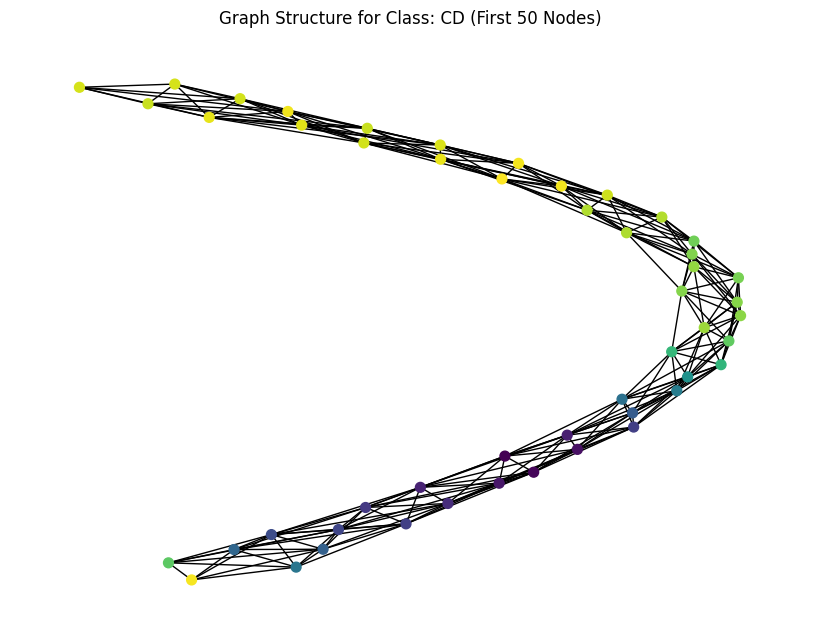

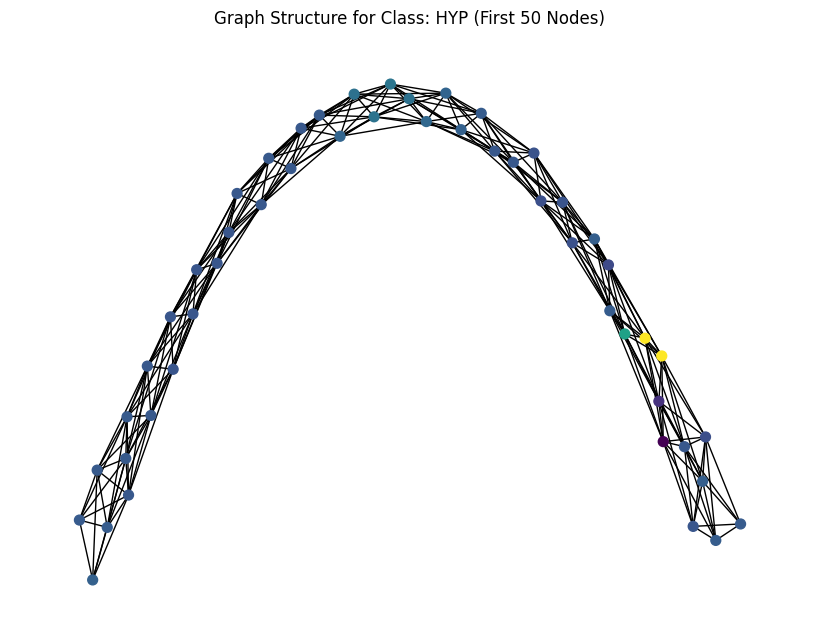

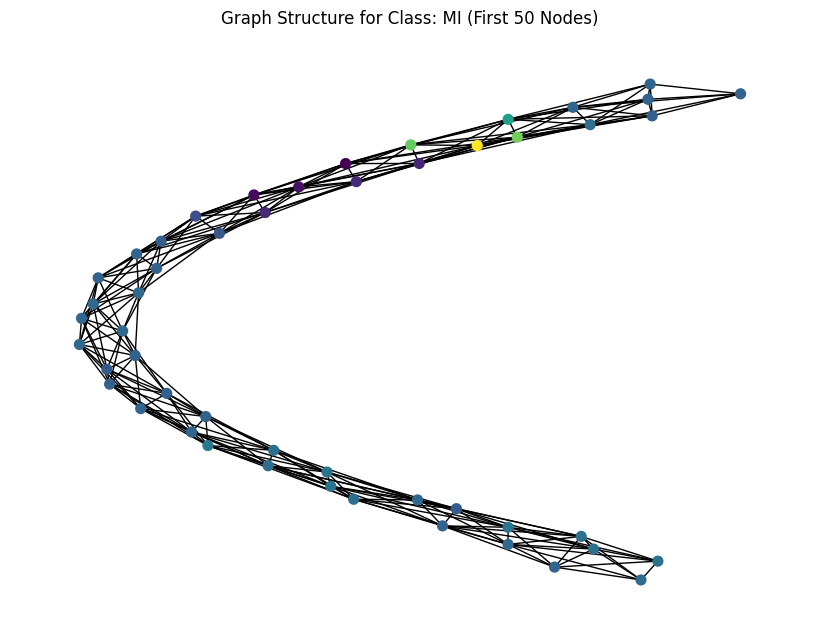

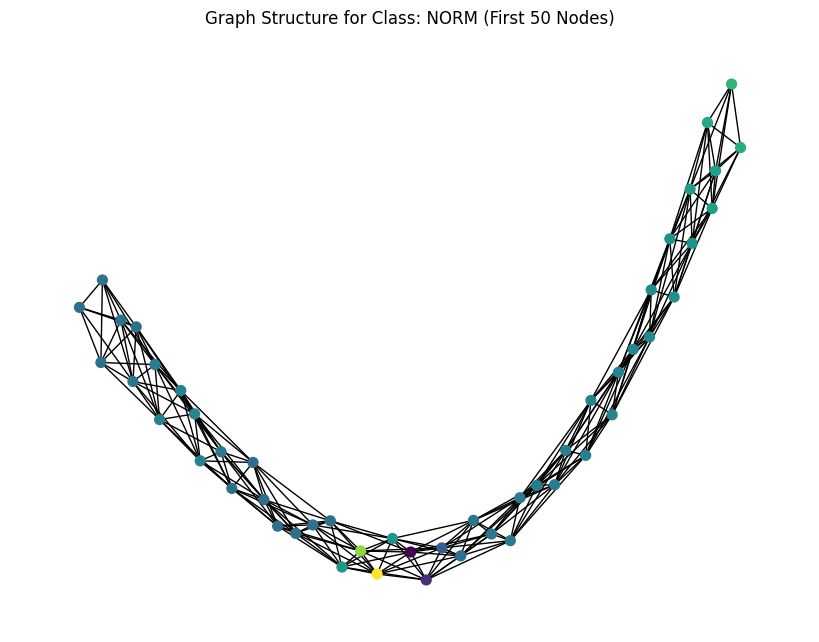

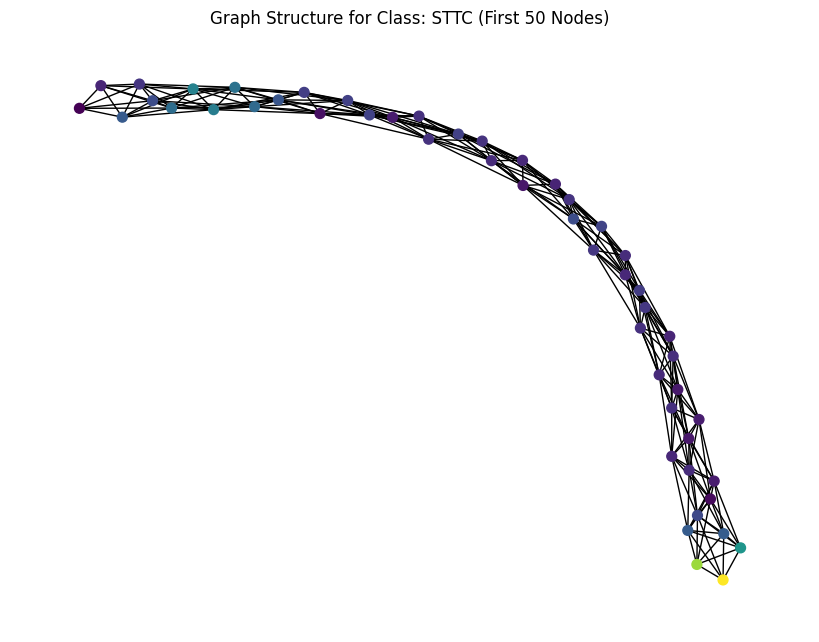

In [8]:
import numpy as np
import pandas as pd
import wfdb
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from scipy.fft import fft
import pywt
import os
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

# Step 1: Set Up the Environment
# Install required libraries
# !pip install wfdb torch-geometric pywavelets networkx matplotlib

# Step 2: Load and Balance the PTB-XL Dataset
def load_and_balance_ptbxl_data(data_path, samples_per_class=3000):
    metadata = pd.read_csv(os.path.join(data_path, 'ptbxl_database.csv'))
    scp_statements = pd.read_csv(os.path.join(data_path, 'scp_statements.csv'))
    
    diagnostic_scp = scp_statements[scp_statements['diagnostic'] == 1]
    valid_statements = diagnostic_scp['Unnamed: 0'].values
    
    def get_superclass(scp_codes):
        scp_codes = eval(scp_codes) if isinstance(scp_codes, str) else scp_codes
        for code, likelihood in scp_codes.items():
            if code in valid_statements and likelihood > 0:
                superclass = diagnostic_scp[diagnostic_scp['Unnamed: 0'] == code]['diagnostic_class'].values
                if len(superclass) > 0:
                    return superclass[0]
        return None
    
    metadata['superclass'] = metadata['scp_codes'].apply(get_superclass)
    metadata = metadata[metadata['superclass'].notnull()]
    
    label_encoder = LabelEncoder()
    metadata['label'] = label_encoder.fit_transform(metadata['superclass'])
    classes = label_encoder.classes_
    
    balanced_metadata = pd.DataFrame()
    for class_name in classes:
        class_data = metadata[metadata['superclass'] == class_name]
        if len(class_data) > samples_per_class:
            class_data = resample(class_data, n_samples=samples_per_class, random_state=42)
        elif len(class_data) < samples_per_class:
            class_data = resample(class_data, n_samples=samples_per_class, replace=True, random_state=42)
        balanced_metadata = pd.concat([balanced_metadata, class_data])
    
    balanced_metadata = balanced_metadata.reset_index(drop=True)
    
    return balanced_metadata, classes

# Step 3: Convert ECG Signals to Graphs
def ecg_to_graph(signal, label, window_size=1000, k=5):
    # Normalize signal
    signal = (signal - np.mean(signal, axis=0)) / (np.std(signal, axis=0) + 1e-8)
    
    if signal.shape[0] < window_size:
        signal = np.pad(signal, ((0, window_size - signal.shape[0]), (0, 0)), mode='constant')
    else:
        signal = signal[:window_size, :]
    
    num_nodes = window_size
    node_features = np.zeros((num_nodes, 18))  # 12 leads + mean + std + 2 FFT + 2 DWT
    for t in range(num_nodes):
        features = signal[t, :]
        node_features[t, :12] = features
        node_features[t, 12:14] = [np.mean(signal[t, :]), np.std(signal[t, :])]
        fft_vals = np.abs(fft(signal[t, :]))[:2]
        node_features[t, 14:16] = fft_vals / (np.max(fft_vals) + 1e-8)
        try:
            coeffs, _ = pywt.cwt(signal[t, :], scales=[1, 2], wavelet='mexh')
            node_features[t, 16:18] = coeffs[:, 0] / (np.max(np.abs(coeffs[:, 0])) + 1e-8)
        except Exception as e:
            print(f"Wavelet transform error at time point {t}: {e}")
            node_features[t, 16:18] = 0
    
    node_features = torch.from_numpy(node_features).float()
    
    # k-Nearest Neighbor edges
    edge_index = []
    for i in range(num_nodes):
        for j in range(i + 1, min(i + k + 1, num_nodes)):
            edge_index.append([i, j])
            edge_index.append([j, i])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    data = Data(x=node_features, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))
    return data

# Step 4: Visualize One Graph per Class
def visualize_graph(graph, class_name, num_nodes_to_plot=50):
    # Convert torch_geometric Data to networkx graph
    G = nx.Graph()
    edge_index = graph.edge_index.t().cpu().numpy()
    node_features = graph.x.cpu().numpy()
    
    # Add nodes (limit to num_nodes_to_plot for clarity)
    for i in range(min(num_nodes_to_plot, graph.num_nodes)):
        G.add_node(i, feature=node_features[i, 12])  # Use mean signal (index 12) for node color
    
    # Add edges (only those involving the first num_nodes_to_plot nodes)
    for i, j in edge_index:
        if i < num_nodes_to_plot and j < num_nodes_to_plot:
            G.add_edge(i, j)
    
    # Plot
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G)
    node_colors = [G.nodes[i]['feature'] for i in G.nodes]
    nx.draw(G, pos, node_size=50, node_color=node_colors, cmap=plt.cm.viridis, with_labels=False)
    plt.title(f"Graph Structure for Class: {class_name} (First {num_nodes_to_plot} Nodes)")
    plt.colorbar(label='Mean Signal Value')
    plt.show()

# Main Execution
if __name__ == "__main__":
    data_path = "/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
    
    # Load and balance data
    metadata, classes = load_and_balance_ptbxl_data(data_path, samples_per_class=3000)
    print(f"Classes: {classes}")
    print(f"Balanced dataset size: {len(metadata)}")
    
    # Select and visualize one graph per class
    for class_name in classes:
        class_data = metadata[metadata['superclass'] == class_name].iloc[0]
        ecg_id = class_data['ecg_id']
        label = class_data['label']
        file_path = os.path.join(data_path, class_data['filename_lr'])
        try:
            signal, _ = wfdb.rdsamp(file_path.replace('.dat', ''))
            graph = ecg_to_graph(signal, label, window_size=1000, k=5)
            print(f"Visualizing graph for ECG {ecg_id} (Class: {class_name})")
            visualize_graph(graph, class_name)
        except Exception as e:
            print(f"Error processing ECG {ecg_id} for visualization: {e}")